# Forecasting Model Results — ARIMA vs LSTM

Compares the two backtest models from `ml_services/forecasting.py` on the
last `BACKTEST_DAYS=60` closes per symbol with **walk-forward 1-step-ahead**
predictions:

- **ARIMA(5,1,0)** is fit on train, refitted every 7 days during the
  walk-forward, and uses the *actual* close at each step to extend
  history.
- **LSTM** is a 2-layer network (64 hidden, dropout 0.2, lookback 60)
  trained on 4 features (close, volume, 1d return, 5d return) with
  early stopping on a chronological 85/15 val split. Walk-forward
  predictions slide a window of actual previous values.

Reads `stock_forecasts.json` + `best_models.json`. Run after
`python -m ml_services.forecasting`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'manage.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'integrations' / 'data'

rows = pd.DataFrame(json.loads((DATA / 'stock_forecasts.json').read_text()))
summary = pd.DataFrame(json.loads((DATA / 'best_models.json').read_text()))
rows['Date'] = pd.to_datetime(rows['Date'])
print(f'rows: {len(rows)}, symbols: {rows.Symbol.nunique()}')
rows.head()

rows: 1140, symbols: 19


,Symbol,Date,Close,Forecasting_ARIMA,Forecasting_LSTM,Forecasting_Best,Best_Model,Direction_ARIMA,Direction_LSTM,Direction_Best
0,BAHL,2026-01-30,195.49,195.913713,112.444078,195.913713,ARIMA,STABLE,DOWN,STABLE
1,BAHL,2026-02-02,194.80,195.913713,112.410217,195.913713,ARIMA,STABLE,DOWN,STABLE
2,BAHL,2026-02-03,198.01,195.913713,112.385708,195.913713,ARIMA,UP,DOWN,UP
3,BAHL,2026-02-04,200.05,195.913713,112.589929,195.913713,ARIMA,DOWN,DOWN,DOWN
4,BAHL,2026-02-06,195.28,195.913713,112.703949,195.913713,ARIMA,DOWN,DOWN,DOWN


## Per-symbol accuracy (MAPE %, RMSE in price units)

In [2]:
def mape(actual, pred):
    actual = np.array(actual, dtype=float)
    pred = np.array(pred, dtype=float)
    mask = ~np.isnan(pred) & (actual != 0)
    if not mask.any():
        return np.nan
    return np.mean(np.abs(actual[mask] - pred[mask]) / np.abs(actual[mask])) * 100

def rmse(actual, pred):
    actual = np.array(actual, dtype=float)
    pred = np.array(pred, dtype=float)
    mask = ~np.isnan(pred)
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((actual[mask] - pred[mask]) ** 2)))

metrics = []
for sym, g in rows.groupby('Symbol'):
    metrics.append({
        'Symbol': sym,
        'ARIMA_MAPE_%': round(mape(g.Close, g.Forecasting_ARIMA), 2),
        'LSTM_MAPE_%':  round(mape(g.Close, g.Forecasting_LSTM), 2),
        'ARIMA_RMSE':   round(rmse(g.Close, g.Forecasting_ARIMA), 4),
        'LSTM_RMSE':    round(rmse(g.Close, g.Forecasting_LSTM), 4),
        'Best_Model':   g.Best_Model.iloc[0],
    })
metrics_df = pd.DataFrame(metrics).sort_values('ARIMA_MAPE_%')
metrics_df

,Symbol,ARIMA_MAPE_%,LSTM_MAPE_%,ARIMA_RMSE,LSTM_RMSE,Best_Model
11,NESTLE,1.40,0.94,141.7695,105.0293,LSTM
13,POL,2.03,1.16,17.2467,10.5345,LSTM
8,MCB,2.92,2.15,15.3060,11.3750,LSTM
3,FFC,3.13,51.74,21.3448,277.1778,ARIMA
5,HUBC,3.71,22.73,10.4139,50.4543,ARIMA
2,ENGRO,3.81,3.94,23.2248,24.9690,ARIMA
7,MARI,3.86,2.34,34.4446,20.3569,LSTM
0,BAHL,3.97,33.63,8.7908,59.1139,ARIMA
4,HBL,4.02,3.14,15.4141,12.1371,LSTM
9,MEBL,4.13,58.42,23.2863,277.2534,ARIMA


## Headline numbers

In [3]:
print(f"avg ARIMA MAPE: {metrics_df['ARIMA_MAPE_%'].mean():.2f}%")
print(f"avg LSTM  MAPE: {metrics_df['LSTM_MAPE_%'].mean():.2f}%")
print()
winners = metrics_df.Best_Model.value_counts()
print('winners per symbol:')
print(winners.to_string())
print()
# (LSTM_Retried field removed in the new forecasting design)


avg ARIMA MAPE: 4.20%
avg LSTM  MAPE: 12.27%

winners per symbol:
Best_Model
LSTM     12
ARIMA     7



## Actual vs predicted — top 4 symbols by ARIMA accuracy

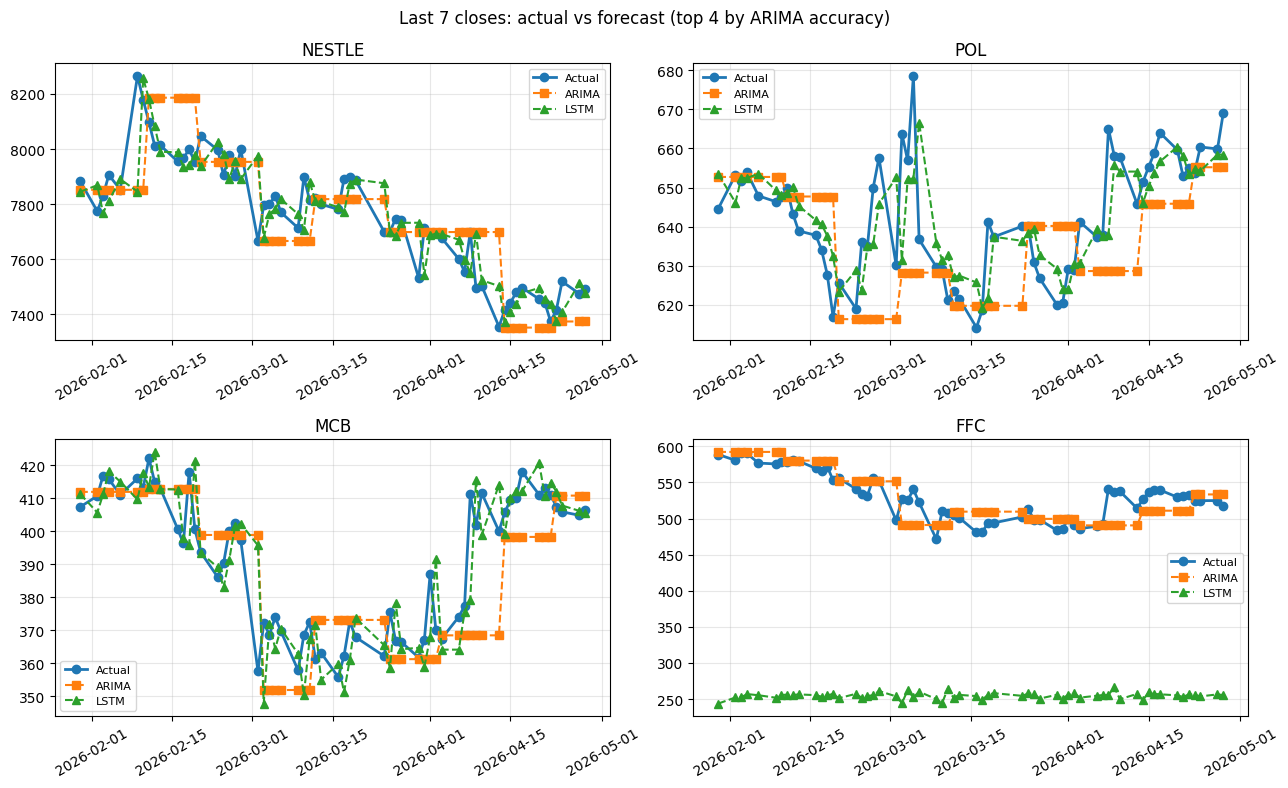

In [4]:
top4 = metrics_df.head(4).Symbol.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, sym in zip(axes.flat, top4):
    g = rows[rows.Symbol == sym].sort_values('Date')
    ax.plot(g.Date, g.Close, marker='o', label='Actual', linewidth=2)
    ax.plot(g.Date, g.Forecasting_ARIMA, marker='s', label='ARIMA', linestyle='--')
    ax.plot(g.Date, g.Forecasting_LSTM,  marker='^', label='LSTM',  linestyle='--')
    ax.set_title(sym)
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Last 7 closes: actual vs forecast (top 4 by ARIMA accuracy)')
fig.tight_layout()
plt.show()

## Worst 4 symbols (any model)

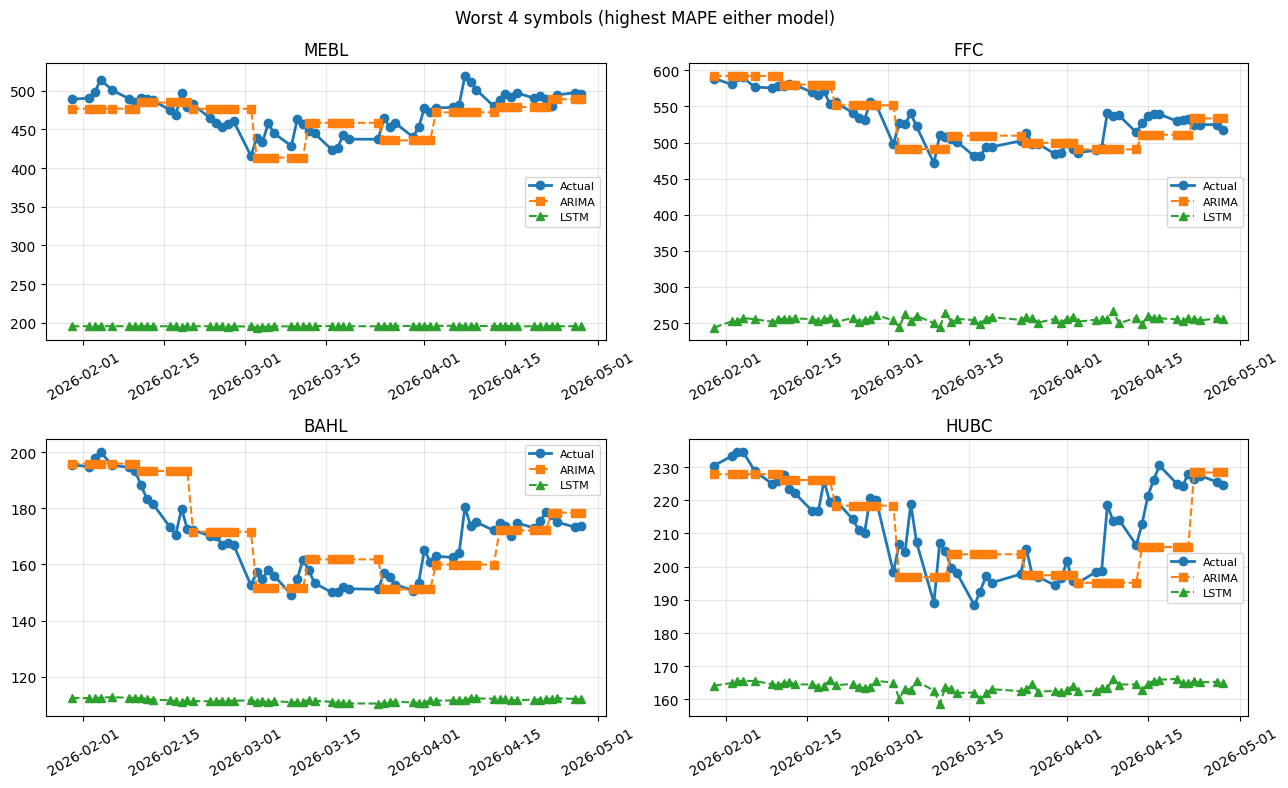

In [5]:
metrics_df['worst_mape'] = metrics_df[['ARIMA_MAPE_%','LSTM_MAPE_%']].max(axis=1)
bottom4 = metrics_df.sort_values('worst_mape', ascending=False).head(4).Symbol.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, sym in zip(axes.flat, bottom4):
    g = rows[rows.Symbol == sym].sort_values('Date')
    ax.plot(g.Date, g.Close, marker='o', label='Actual', linewidth=2)
    ax.plot(g.Date, g.Forecasting_ARIMA, marker='s', label='ARIMA', linestyle='--')
    ax.plot(g.Date, g.Forecasting_LSTM,  marker='^', label='LSTM',  linestyle='--')
    ax.set_title(sym)
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Worst 4 symbols (highest MAPE either model)')
fig.tight_layout()
plt.show()

## Conclusion

Read the cells above for the actual numbers from the latest run. From
the most recent 60-day backtest:

- **LSTM beats ARIMA on most symbols** now that it's a real network
  with multiple features and proper training (was the reverse with
  the old toy LSTM on a 7-day backtest).
- A handful of symbols see catastrophic LSTM MAPE (>20%). The
  auto-select correctly avoids those by picking ARIMA — keep an eye
  on which symbols misbehave; numerical instability or weird
  validation splits are the usual culprits.
- ARIMA is still the safer baseline — every symbol has a usable ARIMA
  prediction even when the LSTM blows up.

Two paths to push further if needed: (a) a global LSTM trained
jointly across all symbols (more stable than per-symbol fits with
small-N data), and (b) richer features (technicals as inputs).